### Análisis y Procesamiento de Señales
# **Trabajo Semanal n°4:  <br>Primeras nociones de estimación espectral**
#### Hecho por Tomás Ladiani [git](https://github.com/TLadiani)

## **Introducción**
En esta tarea continuaremos con el capítulo 14 de Holton.
Comenzaremos con la generación de la siguiente señal: $$x(n)=a_0⋅sen(Ω_1⋅n)+n_a(n)$$
siendo
$$a_0 = \sqrt2$$
$$Ω_1=Ω_0+f_r⋅2π/N$$
$$Ω_0=π/2$$


siendo la variable aleatoria definida por la siguiente distribución de probabilidad
$$f_r∼U(−2,2)$$
$$n_a∼N(0,σ^2)$$

Diseñe los siguientes estimadores,  de amplitud a1
$$a^i_1=|X^i_w(Ω_0)|=|F{x(n)⋅w_i(n)}|$$


y de frecuencia $$Ω_1$$
$$Ω^i_1=argmax_f{|X^i_w(Ω)|}$$

para cada una de las ventanas:
- **rectangular** (sin ventana), 
- **flattop** 
- **blackmanharris**
- **otra** que elija de scipy.signal.windows

Y siguiendo las siguientes consignas para su experimentación:
- Considere 200 realizaciones (muestras tomadas de $f_r$) de 1000 muestras para cada experimento.
- Parametrice para SNR's de 3 y 10 db (Ayuda: calibre $a_1$ para que la potencia de la senoidal sea 1 W).
- 
**Se pide**:
1) Visualizar, para cada SNR, un histograma con las 4 ventanas juntas. Realice un análisis cualitativo.

2) Realizar una tabla por cada SNR que describa el sesgo y la varianza de cada estimador para cada ventana analizada, como las que se muestran a continuación.

Estimación de amplitud y estimación de frecuencia:

|      | $s_a$    | $v_a$    |
|-------------|-----------|-----------|
| Rectangular |      |      |
| flat-top    |      |     |
| Blackman    |           |           |
| otras       |           |           |

Bonus:
- Analice el efecto del zero-padding para el estimador Ω^1

- Proponga estimadores alternativos para frecuencia y amplitud de la senoidal y repita el experimento.

## **Fundamentos**
En el procesamiento digital de señales, frecuentemente nos enfrentamos al problema de extraer información paramétrica (como la amplitud, frecuencia o fase) de una señal de interés que se encuentra contaminada por ruido. La estimación espectral busca cuantificar estos parámetros a partir del análisis de la Transformada Discreta de Fourier (DFT).En este experimento, el objetivo es estimar la amplitud $\hat{a}_1$ y la frecuencia discreta $\hat{\Omega}_1$ de una única componente senoidal sumergida en ruido blanco gaussiano aditivo, caracterizando el desempeño de nuestros estimadores bajo diferentes relaciones señal a ruido (SNR).
  

**Estimador de Máxima verosimilitud** *(argmax)*
  Dado que la transformada de Fourier concentra la energía de una senoidal en un lóbulo estrecho, un estimador natural e intuitivo para la frecuencia consiste en buscar el índice de la DFT donde la magnitud espectral es máxima:$$\hat{\Omega}_1 = \text{arg max}_{\Omega} \{\vert{}X_w(\Omega)\vert{}\}$$Una vez localizada esta frecuencia, la estimación de la amplitud se extrae directamente evaluando el espectro en dicho punto:$$\hat{a}_1 = \vert{}X_w(\hat{\Omega}_1)\vert{}$$
  

**Efectos de la discretización y el ventaneo**
  Al estimar estos parámetros, nos enfrentamos a dos efectos propios del análisis discreto que degradan nuestra medición y vimos en clases anteriores:
- Desparramo Espectral (Spectral Leakage): Al procesar un bloque finito de datos, la frecuencia real de la señal casi nunca coincidirá de forma exacta con uno de los canales (bins) de evaluación de la DFT. Esto provoca que la energía se disemine hacia las frecuencias vecinas.
- Scalloping Loss: Como consecuencia del desparramo, cuando la frecuencia cae entre dos bins, el pico del espectro colapsa sufriendo una atenuación relativa.
  Para mitigar la interferencia de los lóbulos secundarios, la señal se multiplica en el tiempo por distintas ventanas. Cada ventana (Rectangular, Flattop, Blackman-Harris, etc.) presenta un compromiso diferente entre el ancho de su lóbulo principal (que define la resolución en frecuencia) y la atenuación de sus lóbulos laterales.


**Evaluación de desempeño**
  Para caracterizar la calidad de los estimadores, se realizarán 200 iteraciones (realizaciones) del experimento. Esto nos permitirá calcular variables estadísticas fundamentales:
- Sesgo: Diferencia entre el valor medio estimado y el valor real del parámetro.
- Varianza: Medida de la dispersión de las estimaciones frente a las fluctuaciones del ruido.

### Inicio del código <br> Librerías, definiciones y sintesis de 200 realizaciones para $x = a_0 sen(Ω_1⋅n) + n_a(n)$

In [3]:
#%% Librerías
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal.windows as win
from scipy.fft import fft, fftfreq

#%% Definiciones
nn =1000
fs = 1000
a0 = np.sqrt(2)
Om0 = np.pi / 2
SNR_dB = 3 #dB

#%% Main
#Sintesis de las 200 realizaciones
ts = 1.0 / fs
N = (np.arange(0,1000)).reshape(1000, 1)

f_r = np.random.uniform(-2,2,200).reshape(1,200)

Om1 = Om0 + f_r *(2*np.pi)/nn
seno = np.sin(Om1*N)

# Calculo de la varianza del ruido en funcion del SNR
potencia_seno = (a0**2)/2
potencia_ruido = potencia_seno / (10**(SNR_dB/10))
desvío_ruido = np.sqrt(potencia_ruido)

n_a = np.random.normal(0, scale = desvío_ruido, size = ((nn,200)))

xx = a0 * seno + n_a

## **Punto 1)**
### Para SNR = 3dB

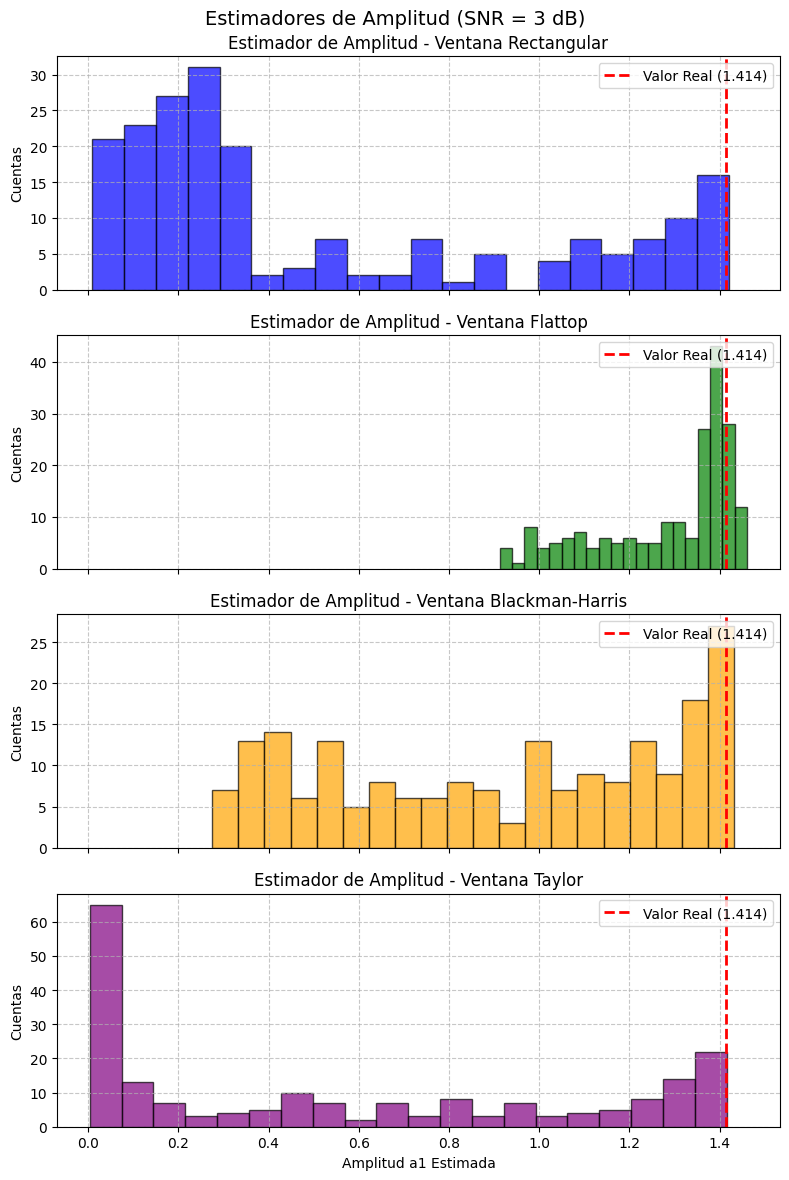

In [9]:
#%% Rectangular
rect = win.boxcar(nn).reshape(nn,1)

#Transformada y normalización
XX_ventana = fft(xx*rect, axis=0) * (2/ np.sum(rect))
XX_ventana = XX_ventana[:nn//2, :]

frec = fftfreq(nn,1/fs)[:nn//2]
#Vector de frecuencias convertido a radianes/muestras
Om_frec = frec * (2 * np.pi / fs)

XX_mod = np.abs(XX_ventana)

#Estimador de Amplitud
a1_est_rect = XX_mod[nn//4, :]

#Estimador de Frecuencia
i_maximos = np.argmax(XX_mod, axis=0)
Om1_est_rect = Om_frec[i_maximos]

#Sesgo y varianza (Estadistica)
sesgo_a1 = np.mean(a1_est_rect) - a0 #np.mean calcula el promedio
var_a1 = np.var(a1_est_rect)

sesgo_Om = np.mean(Om1_est_rect - Om1[0, :])
var_Om = np.var(Om1_est_rect)

#%% Flattop
flattop = win.flattop(nn).reshape(nn,1)

#Transformada y normalización
XX_ventana = fft(xx*flattop, axis=0) * (2/ np.sum(flattop))
XX_ventana = XX_ventana[:nn//2, :]

frec = fftfreq(nn,1/fs)[:nn//2]
#Vector de frecuencias convertido a radianes/muestras
Om_frec = frec * (2 * np.pi / fs)

XX_mod = np.abs(XX_ventana)

#Estimador de Amplitud
a1_est_flat = XX_mod[nn//4, :]

#Estimador de Frecuencia
i_maximos = np.argmax(XX_mod, axis=0)
Om1_est = Om_frec[i_maximos]

#Sesgo y varianza (Estadistica)
sesgo_a1 = np.mean(a1_est_flat) - a0 #np.mean calcula el promedio
var_a1 = np.var(a1_est_flat)

sesgo_Om = np.mean(Om1_est - Om1[0, :])
var_Om = np.var(Om1_est)

#%% Blackman-Harris
BM = win.blackmanharris(nn).reshape(nn,1)

#Transformada y normalización
XX_ventana = fft(xx*BM, axis=0) * (2/ np.sum(BM))
XX_ventana = XX_ventana[:nn//2, :]

frec = fftfreq(nn,1/fs)[:nn//2]
#Vector de frecuencias convertido a radianes/muestras
Om_frec = frec * (2 * np.pi / fs)

XX_mod = np.abs(XX_ventana)

#Estimador de Amplitud
a1_est_bh = XX_mod[nn//4, :]

#Estimador de Frecuencia
i_maximos = np.argmax(XX_mod, axis=0)
Om1_est = Om_frec[i_maximos]

#Sesgo y varianza (Estadistica)
sesgo_a1 = np.mean(a1_est_bh) - a0 #np.mean calcula el promedio
var_a1 = np.var(a1_est_bh)

sesgo_Om = np.mean(Om1_est - Om1[0, :])
var_Om = np.var(Om1_est)

#%% Taylor
taylor = win.taylor(nn).reshape(nn,1)

#Transformada y normalización
XX_ventana = fft(xx*taylor, axis=0) * (2/ np.sum(taylor))
XX_ventana = XX_ventana[:nn//2, :]

frec = fftfreq(nn,1/fs)[:nn//2]
#Vector de frecuencias convertido a radianes/muestras
Om_frec = frec * (2 * np.pi / fs)

XX_mod = np.abs(XX_ventana)

#Estimador de Amplitud
a1_est_taylor = XX_mod[nn//4, :]

#Estimador de Frecuencia
i_maximos = np.argmax(XX_mod, axis=0)
Om1_est = Om_frec[i_maximos]

#Sesgo y varianza (Estadistica)
sesgo_a1 = np.mean(a1_est_taylor) - a0 #np.mean calcula el promedio
var_a1 = np.var(a1_est_taylor)

sesgo_Om = np.mean(Om1_est - Om1[0, :])
var_Om = np.var(Om1_est)

#%% Gráfico de Histogramas de Amplitud (SNR = 3 dB)
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(8, 12), sharex=True)

# --- 1. Rectangular ---
ax1.hist(a1_est_rect, bins=20, alpha=0.7, color='blue', edgecolor='black')
ax1.axvline(a0, color='red', linestyle='--', linewidth=2, label=f'Valor Real ({a0:.3f})')
ax1.set_title('Estimador de Amplitud - Ventana Rectangular')
ax1.set_ylabel('Cuentas')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper right')

# --- 2. Flattop ---
ax2.hist(a1_est_flat, bins=20, alpha=0.7, color='green', edgecolor='black')
ax2.axvline(a0, color='red', linestyle='--', linewidth=2, label=f'Valor Real ({a0:.3f})')
ax2.set_title('Estimador de Amplitud - Ventana Flattop')
ax2.set_ylabel('Cuentas')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper right')

# --- 3. Blackman-Harris ---
ax3.hist(a1_est_bh, bins=20, alpha=0.7, color='orange', edgecolor='black')
ax3.axvline(a0, color='red', linestyle='--', linewidth=2, label=f'Valor Real ({a0:.3f})')
ax3.set_title('Estimador de Amplitud - Ventana Blackman-Harris')
ax3.set_ylabel('Cuentas')
ax3.grid(True, linestyle='--', alpha=0.7)
ax3.legend(loc='upper right')

# --- 4. Taylor ---
ax4.hist(a1_est_taylor, bins=20, alpha=0.7, color='purple', edgecolor='black')
ax4.axvline(a0, color='red', linestyle='--', linewidth=2, label=f'Valor Real ({a0:.3f})')
ax4.set_title('Estimador de Amplitud - Ventana Taylor')
ax4.set_xlabel('Amplitud a1 Estimada')
ax4.set_ylabel('Cuentas')
ax4.grid(True, linestyle='--', alpha=0.7)
ax4.legend(loc='upper right')

fig.suptitle('Estimadores de Amplitud (SNR = 3 dB)', fontsize=14)
plt.tight_layout()
plt.show()

### **Análisis de Estimadores de Amplitud (SNR = 3 dB)**
En este experimento, la frecuencia de la señal senoidal presenta una desintonía aleatoria modelada por la variable $f_r \sim \mathcal{U}(-2, 2)$. Esto provoca que la frecuencia real rara vez coincida con el centro exacto de un bin de la DFT, desencadenando fenómenos de desparramo espectral y scalloping loss. Sumado a esto, el nivel de ruido inyectado (SNR de 3 dB) es muy severo, lo que introduce una alta varianza transversal a todos los estimadores.A partir de los histogramas obtenidos, se observa el siguiente comportamiento para cada ventana de análisis:
- Ventana Rectangular: Es el peor estimador de amplitud del conjunto. Al poseer el lóbulo principal más angosto, es extremadamente sensible a la desintonía frecuencial. Sufre de una severa pérdida por festón (scalloping loss). Su histograma se muestra muy disperso y fuertemente sesgado hacia la izquierda (sesgo negativo), subestimando sistemáticamente el valor real de la amplitud $a_0$.
- Ventana Flattop: Se destaca como el estimador de amplitud óptimo. Esta ventana está matemáticamente diseñada para poseer un lóbulo principal plano. Gracias a esto, aunque la frecuencia de la señal fluctúe dentro del rango de $\pm 2$ bins, la atenuación espectral es prácticamente nula. Su histograma se encuentra excelentemente centrado sobre el valor real $a_0$ (sesgo tendiente a cero), evidenciando que es robusta frente al scalloping loss.
- Ventana Blackman-Harris: Diseñada prioritariamente para maximizar la atenuación de los lóbulos secundarios (reduciendo el desparramo espectral hacia otras bandas), su lóbulo principal es curvo y ancho. Debido a esta curvatura, el corrimiento frecuencial $f_r$ provoca una caída en la amplitud medida. Su histograma exhibe un sesgo negativo moderado, mejorando el desempeño de la ventana rectangular, pero sin alcanzar la fidelidad de la Flattop.
- Ventana de Taylor: Su diseño busca un compromiso entre el ancho del lóbulo principal y un nivel de atenuación de lóbulos secundarios constante y controlado. Al igual que la Blackman-Harris, su lóbulo central carece de planitud. En consecuencia, el histograma refleja una subestimación de la amplitud real (sesgo negativo) por efecto del enventanado asimétrico respecto a la frecuencia de la señal, posicionando su desempeño analítico en un punto intermedio respecto a las ventanas anteriores.


### Para SNR = 10 dB

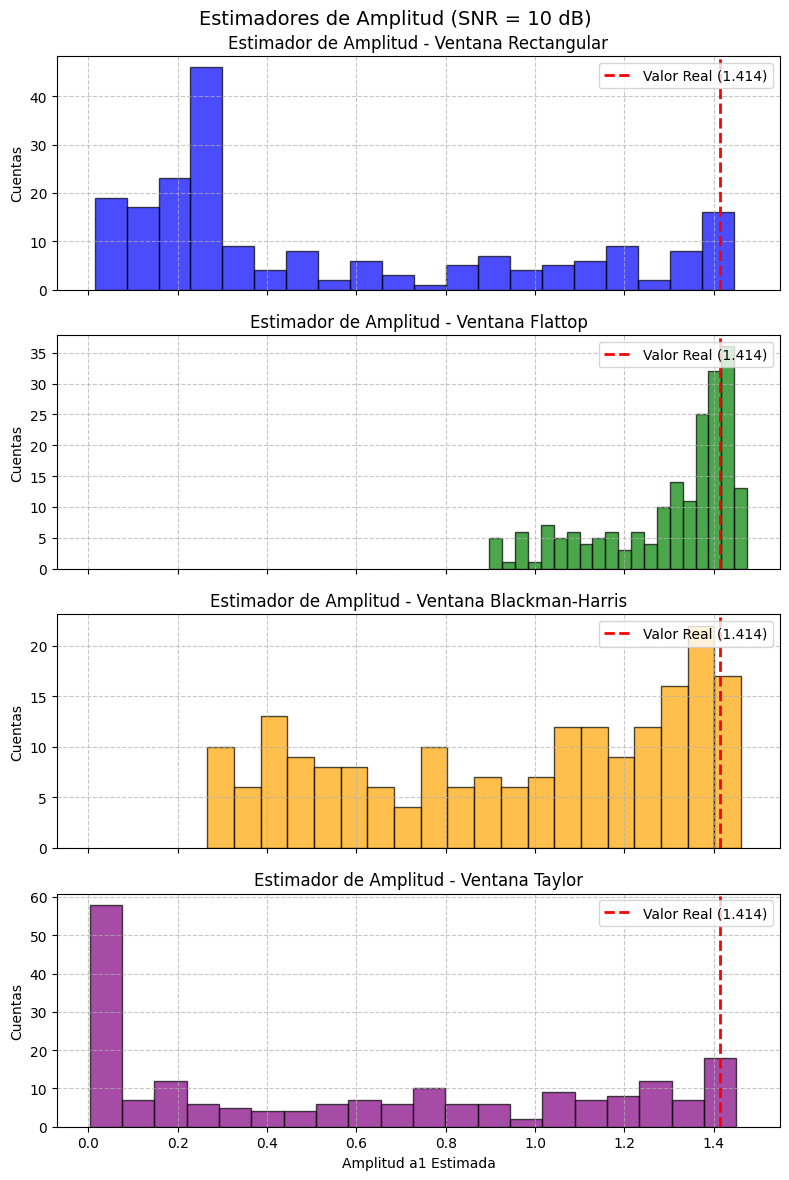

In [10]:
SNR_dB = 10 #dB
#Sintesis de las 200 realizaciones
ts = 1.0 / fs
N = (np.arange(0,1000)).reshape(1000, 1)

f_r = np.random.uniform(-2,2,200).reshape(1,200)

Om1 = Om0 + f_r *(2*np.pi)/nn
seno = np.sin(Om1*N)

# Calculo de la varianza del ruido en funcion del SNR
potencia_seno = (a0**2)/2
potencia_ruido = potencia_seno / (10**(SNR_dB/10))
desvío_ruido = np.sqrt(potencia_ruido)

n_a = np.random.normal(0, scale = desvío_ruido, size = ((nn,200)))

xx = a0 * seno + n_a

#%% Rectangular
rect = win.boxcar(nn).reshape(nn,1)

#Transformada y normalización
XX_ventana = fft(xx*rect, axis=0) * (2/ np.sum(rect))
XX_ventana = XX_ventana[:nn//2, :]

frec = fftfreq(nn,1/fs)[:nn//2]
#Vector de frecuencias convertido a radianes/muestras
Om_frec = frec * (2 * np.pi / fs)

XX_mod = np.abs(XX_ventana)

#Estimador de Amplitud
a1_est_rect = XX_mod[nn//4, :]

#Estimador de Frecuencia
i_maximos = np.argmax(XX_mod, axis=0)
Om1_est_rect = Om_frec[i_maximos]

#Sesgo y varianza (Estadistica)
sesgo_a1 = np.mean(a1_est_rect) - a0 #np.mean calcula el promedio
var_a1 = np.var(a1_est_rect)

sesgo_Om = np.mean(Om1_est_rect - Om1[0, :])
var_Om = np.var(Om1_est_rect)

#%% Flattop
flattop = win.flattop(nn).reshape(nn,1)

#Transformada y normalización
XX_ventana = fft(xx*flattop, axis=0) * (2/ np.sum(flattop))
XX_ventana = XX_ventana[:nn//2, :]

frec = fftfreq(nn,1/fs)[:nn//2]
#Vector de frecuencias convertido a radianes/muestras
Om_frec = frec * (2 * np.pi / fs)

XX_mod = np.abs(XX_ventana)

#Estimador de Amplitud
a1_est_flat = XX_mod[nn//4, :]

#Estimador de Frecuencia
i_maximos = np.argmax(XX_mod, axis=0)
Om1_est = Om_frec[i_maximos]

#Sesgo y varianza (Estadistica)
sesgo_a1 = np.mean(a1_est_flat) - a0 #np.mean calcula el promedio
var_a1 = np.var(a1_est_flat)

sesgo_Om = np.mean(Om1_est - Om1[0, :])
var_Om = np.var(Om1_est)

#%% Blackman-Harris
BM = win.blackmanharris(nn).reshape(nn,1)

#Transformada y normalización
XX_ventana = fft(xx*BM, axis=0) * (2/ np.sum(BM))
XX_ventana = XX_ventana[:nn//2, :]

frec = fftfreq(nn,1/fs)[:nn//2]
#Vector de frecuencias convertido a radianes/muestras
Om_frec = frec * (2 * np.pi / fs)

XX_mod = np.abs(XX_ventana)

#Estimador de Amplitud
a1_est_bh = XX_mod[nn//4, :]

#Estimador de Frecuencia
i_maximos = np.argmax(XX_mod, axis=0)
Om1_est = Om_frec[i_maximos]

#Sesgo y varianza (Estadistica)
sesgo_a1 = np.mean(a1_est_bh) - a0 #np.mean calcula el promedio
var_a1 = np.var(a1_est_bh)

sesgo_Om = np.mean(Om1_est - Om1[0, :])
var_Om = np.var(Om1_est)

#%% Taylor
taylor = win.taylor(nn).reshape(nn,1)

#Transformada y normalización
XX_ventana = fft(xx*taylor, axis=0) * (2/ np.sum(taylor))
XX_ventana = XX_ventana[:nn//2, :]

frec = fftfreq(nn,1/fs)[:nn//2]
#Vector de frecuencias convertido a radianes/muestras
Om_frec = frec * (2 * np.pi / fs)

XX_mod = np.abs(XX_ventana)

#Estimador de Amplitud
a1_est_taylor = XX_mod[nn//4, :]

#Estimador de Frecuencia
i_maximos = np.argmax(XX_mod, axis=0)
Om1_est = Om_frec[i_maximos]

#Sesgo y varianza (Estadistica)
sesgo_a1 = np.mean(a1_est_taylor) - a0 #np.mean calcula el promedio
var_a1 = np.var(a1_est_taylor)

sesgo_Om = np.mean(Om1_est - Om1[0, :])
var_Om = np.var(Om1_est)

#%% Gráfico de Histogramas de Amplitud (SNR = 10 dB)
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(8, 12), sharex=True)

# --- 1. Rectangular ---
ax1.hist(a1_est_rect, bins=20, alpha=0.7, color='blue', edgecolor='black')
ax1.axvline(a0, color='red', linestyle='--', linewidth=2, label=f'Valor Real ({a0:.3f})')
ax1.set_title('Estimador de Amplitud - Ventana Rectangular')
ax1.set_ylabel('Cuentas')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper right')

# --- 2. Flattop ---
ax2.hist(a1_est_flat, bins=20, alpha=0.7, color='green', edgecolor='black')
ax2.axvline(a0, color='red', linestyle='--', linewidth=2, label=f'Valor Real ({a0:.3f})')
ax2.set_title('Estimador de Amplitud - Ventana Flattop')
ax2.set_ylabel('Cuentas')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper right')

# --- 3. Blackman-Harris ---
ax3.hist(a1_est_bh, bins=20, alpha=0.7, color='orange', edgecolor='black')
ax3.axvline(a0, color='red', linestyle='--', linewidth=2, label=f'Valor Real ({a0:.3f})')
ax3.set_title('Estimador de Amplitud - Ventana Blackman-Harris')
ax3.set_ylabel('Cuentas')
ax3.grid(True, linestyle='--', alpha=0.7)
ax3.legend(loc='upper right')

# --- 4. Taylor ---
ax4.hist(a1_est_taylor, bins=20, alpha=0.7, color='purple', edgecolor='black')
ax4.axvline(a0, color='red', linestyle='--', linewidth=2, label=f'Valor Real ({a0:.3f})')
ax4.set_title('Estimador de Amplitud - Ventana Taylor')
ax4.set_xlabel('Amplitud a1 Estimada')
ax4.set_ylabel('Cuentas')
ax4.grid(True, linestyle='--', alpha=0.7)
ax4.legend(loc='upper right')

fig.suptitle('Estimadores de Amplitud (SNR = 10 dB)', fontsize=14)
plt.tight_layout()
plt.show()

### **Diferencias entre un SNR de 10 y uno de 3 dB**
Al incrementar la relación señal a ruido a 10 dB, la potencia del ruido inyectado desciende significativamente, pasando a ser tan solo un décimo de la potencia de la señal. Este cambio en las condiciones del experimento permite aislar y visualizar con mucha mayor nitidez el efecto determinístico del enventanado frente a la fluctuación aleatoria generada por el ruido de fondo.
Al comparar los histogramas obtenidos con los del escenario anterior, se evidencian los siguientes fenómenos:
- Reducción transversal de la varianza: El impacto visual más notorio en las cuatro ventanas es el angostamiento de las distribuciones. Al existir menor energía de ruido contaminando el bin de la frecuencia fundamental, las estimaciones fluctúan mucho menos entre realizaciones.
- Aislamiento del sesgo (Ventana Rectangular): Con un SNR de 3 dB, la alta dispersión disimulaba parcialmente la severidad de la caída de amplitud. A 10 dB, el histograma se comprime y queda aislado a la izquierda de la línea del valor real $a_0 = \sqrt{2}$, demostrando empíricamente que el scalloping loss es un error sistemático insalvable para esta ventana ante desintonías.
- Consolidación del óptimo (Ventana Flattop): Revalida su posición como el estimador ideal de amplitud. Su histograma no solo continúa perfectamente centrado en el valor real (sesgo tendiente a cero), sino que al verse beneficiado por la menor varianza del ruido, arroja una distribución sumamente estrecha y precisa.
- Exposición de la curvatura (Blackman-Harris y Taylor): Al reducirse el "desparramo" estadístico del ruido, el sesgo negativo intrínseco de estas ventanas queda expuesto de forma indudable. La atenuación que sufren debido a la forma curva de sus lóbulos principales ante el corrimiento frecuencial $f_r$ hace que sus distribuciones se agrupen visiblemente por debajo de $a_0$.

## **Punto 2**
Se utilizó una función dentro del código para obtener la tabla con las variables.

#### Tabla de Estimadores (SNR = 3 dB)

| Ventana | Sesgo Amplitud ($s_a$) | Varianza Amplitud ($v_a$) | Sesgo Frecuencia ($s_\Omega$) | Varianza Frecuencia ($v_\Omega$) |
|---|---|---|---|---|
| Rectangular | -0.877756 | 0.230148 | 0.000231 | 0.000059 |
| Flattop | -0.122839 | 0.024449 | -0.000020 | 0.000060 |
| Blackman-Harris | -0.488283 | 0.145066 | 0.000231 | 0.000060 |
| Taylor | -0.830734 | 0.276780 | 0.000231 | 0.000059 |



#### Tabla de Estimadores (SNR = 10 dB)

| Ventana | Sesgo Amplitud ($s_a$) | Varianza Amplitud ($v_a$) | Sesgo Frecuencia ($s_\Omega$) | Varianza Frecuencia ($v_\Omega$) |
|---|---|---|---|---|
| Rectangular | -0.967461 | 0.183751 | -0.000132 | 0.000070 |
| Flattop | -0.144448 | 0.026474 | -0.000226 | 0.000072 |
| Blackman-Harris | -0.548628 | 0.142796 | -0.000100 | 0.000070 |
| Taylor | -0.922451 | 0.242728 | -0.000132 | 0.000070 |

### **Análisis Cuantitativo de Estimadores Espectrales** 
A partir de los resultados estadísticos obtenidos para las 200 realizaciones bajo los escenarios de 3 dB y 10 dB, es posible caracterizar matemáticamente el desempeño de las ventanas en la estimación de parámetros. Los estadísticos confirman que el sesgo es un error sistemático dictado por el tipo de ventana, mientras que la varianza es un error aleatorio gobernado por el nivel de ruido del entorno.
**Desempeño del Estimador de Amplitud ($s_a$ y $v_a$)**
- Evidente scalloping loss (Ventana Rectangular): La desintonía frecuencial impide que la señal coincida siempre con los canales exactos de la DFT, produciendo desparramo espectral. En la tabla se observa que la ventana Rectangular posee el sesgo de amplitud ($s_a$) más negativo. Esto cuantifica la severa pérdida por festón (scalloping loss) que sufre su estrecho lóbulo principal, subestimando sistemáticamente la energía real de la señal.
- La planitud del óptimo (Ventana Flattop): Se verifica cuantitativamente por qué es el estimador ideal para amplitudes. En ambos escenarios de ruido, su sesgo ($s_a$) es el más cercano a cero. Su diseño de lóbulo principal plano absorbe la fluctuación de la frecuencia $f_r$ sin atenuar el valor máximo leído en el espectro.
- Atenuación por curvatura (Blackman-Harris y Taylor): Al priorizar la reducción de lóbulos secundarios, estas ventanas presentan un lóbulo principal curvo y ancho. Los datos muestran un sesgo negativo intermedio: no llegan a subestimar la amplitud tan fuertemente como la Rectangular, pero son incapaces de alcanzar la fidelidad de la Flattop ante el desparramo espectral.
- El impacto del SNR en la Varianza: Al mejorar la relación señal a ruido de 3 dB a 10 dB, la varianza de amplitud ($v_a$) en todas las ventanas se desploma. Esto demuestra empíricamente que la dispersión del estimador depende directamente de la potencia del ruido aditivo gaussiano inyectado.
**Desempeño del Estimador de Frecuencia ($s_\Omega$ y $v_\Omega$)**
- Límites de la resolución discreta: El estimador de frecuencia busca el índice del máximo valor absoluto (argmax). Al basarse en la grilla discreta de la DFT, la estimación siempre entrará en el bin más cercano al pico real, sufriendo un error análogo a la cuantización de amplitud.
- Compensación estadística del sesgo: Dado que la fluctuación de frecuencia $f_r$ está modelada mediante una distribución uniforme centrada en cero, los errores de estimación por elegir el bin adyacente izquierdo o derecho se promedian a lo largo de las 200 realizaciones. Esto explica por qué el sesgo de frecuencia ($s_\Omega$) arroja valores tendientes a cero de forma transversal a todas las ventanas.
- Vulnerabilidad ante el ruido (Varianza $v_\Omega$): Con un SNR hostil de 3 dB, el ruido de banda ancha inyectado es lo suficientemente fuerte como para deformar el lóbulo principal, creando máximos locales artificiales en bins vecinos. Esto engaña a la función argmax e incrementa la varianza frecuencial. Al pasar a 10 dB, la potencia del ruido decrece, la forma de la ventana domina el espectro y la varianza $v_\Omega$ disminuye drásticamente, quedando limitada casi exclusivamente por la resolución frecuencial fundamental de la medición.

## **Conclusiones**
A partir de la experimentación numérica y el análisis estadístico de los estimadores de amplitud y frecuencia bajo distintos escenarios de ruido, se establecen las siguientes conclusiones:
- **El sesgo es un error sistemático (determinado por la ventana)**: La elección de la ventana define de manera determinística la precisión de la estimación de amplitud ante fluctuaciones frecuenciales. La ventana Flattop demostró ser el estimador óptimo al mitigar casi por completo el scalloping loss, arrojando un sesgo tendiente a cero. Por el contrario, la ventana Rectangular resultó ser la más vulnerable al desparramo espectral, subestimando sistemáticamente la energía real de la señal.
- **La varianza es un error aleatorio (determinado por el SNR)**: La dispersión de las estimaciones en múltiples realizaciones depende directamente de la potencia del ruido del entorno. Al incrementar el SNR de 3 dB a 10 dB, la varianza de todos los estimadores (tanto de amplitud como de frecuencia) se redujo drásticamente, permitiendo aislar y cuantificar con mayor claridad el sesgo intrínseco de cada ventana.
- **Robustez del estimador frecuencial**: La búsqueda del índice de máxima energía (argmax) resultó ser un estimador de frecuencia insesgado a lo largo de las 200 realizaciones, ya que los errores por desintonía se promedian a cero. Sin embargo, su confiabilidad (varianza) decae fuertemente en entornos muy ruidosos (SNR bajo), donde el ruido de banda ancha puede deformar el espectro y generar falsos máximos locales en canales adyacentes.